# Guardian ruins parameter analyses 

This notebook is set up to perform analyses on system and body parameters of Guardian ruins known as of 29/Aug/2026.

## Data import and processing

### Import CSV file generated by Seventh Circle

In [1]:
import pandas as pd
import numpy as np

input_data = pd.read_csv("data/GuardianLogs-FullRuinsData.csv", dtype={"Materials": "string"}, keep_default_na=False)

#lines = 1
#display(input_data.head(lines).style.set_table_attributes('style="display:block; overflow-x:auto; white-space:nowrap;"'))

### Process DF to parse materials and remove some unnecessary strings

In [2]:
# Element symbols
symbols = {
    "Antimony":"Sb", "Arsenic":"As", "Cadmium":"Cd", "Carbon":"C", "Chromium":"Cr", "Germanium":"Ge", "Iron":"Fe", "Manganese":"Mn", "Mercury":"Hg",
    "Molybdenum":"Mo", "Nickel":"Ni", "Niobium":"Nb", "Phosphorus":"P", "Polonium":"Po", "Ruthenium":"Ru", "Selenium":"Se", "Sulphur":"S", "Technetium":"Tc",
    "Tellurium":"Te", "Tin":"Sn", "Tungsten":"W", "Vanadium":"V", "Yttrium":"Y", "Zinc":"Zn", "Zirconium":"Zr"
}

# Process imported df to parse elements
processed_data = input_data.drop(columns="Materials").copy()
parsed = processed_data.index.to_series().to_frame("row").join(input_data["Materials"].str.extractall(r"([^:,]+):\s*([\d.]+%)").rename(columns={0:"item", 1:"value"}).reset_index(level=1, drop=True).rename_axis(None))
parsed["item"] = parsed["item"].str.strip().map(symbols)
parsed["value"] = parsed["value"].str.rstrip("%").astype(float)
parsed = parsed.pivot(columns="item", values="value").reindex(columns=symbols.values(), fill_value=0)
parsed.columns = [f"{symbol} (%)" for symbol in parsed.columns]
processed_data = processed_data.join(parsed).fillna(0)

# Rename some columns, remove unnecessary strings, turn booleans into strings
processed_data = processed_data.rename(columns={"Surface Pressure (Atmospheres)": "Surface Pressure (atm)", "Luminosity": "Star Luminosity", "Spectral Class": "Star Spectral Class", "Absolute Magnitude": "Star Absolute Magnitude", "Age": "Star Age (Myr)", "Surface Temperature": "Star Surface Temperature (K)", "Body Radius": "Body Radius (km)", "Gravity": "Gravity (g)"})
processed_data["Parent Subtype"] = processed_data["Parent Subtype"].str.replace(" (Brown dwarf)", "", regex=False).replace("", "n/a")
processed_data["Body Subtype"] = processed_data["Body Subtype"].replace({"High metal content world": "HMC", "Rocky body": "Rocky"})
processed_data["Volcanism"] = processed_data["Volcanism"].replace({"": "n/a", "No volcanism": "No"})
processed_data["Atmosphere"] = processed_data["Atmosphere"].replace("No atmosphere", "none")
processed_data["Tidally Locked"] = processed_data["Tidally Locked"].astype(str)

lines = 10
display(processed_data.head(lines).style.set_properties(**{"white-space": "nowrap"}).set_table_attributes('style="display:block; overflow-x:auto;"'))

,Reference,ID64,System Name,Mod(8),Mass Code,Body,Ruin Index,Site Type,EDx,EDy,EDz,Surface Lattitude,Surface Longitude,Active Monolith Count,Region,Primary Star Type,Star Luminosity,Star Spectral Class,Star Absolute Magnitude,Star Age (Myr),Star Surface Temperature (K),Number of Stars,Body Count,Body Name,Body ID64,Body ID,Body Type,Body Subtype,Tidally Locked,Distance to Arrival,Rotational Period,Semi Major Axis,Arg of Periapsis,Axial Tilt,Orbital Eccentricity,Orbital Inclination,Orbital Period,Orbital Syncronicity,Parent ID,Parent Type,Parent Subtype,Body Radius (km),Earth Masses,Surface Temperature (K),Gravity (g),Body Ice (%),Body Metal (%),Body Rock (%),Volcanism,Atmosphere,Surface Pressure (atm),Orbital Period (days),Terraforming State,Sb (%),As (%),Cd (%),C (%),Cr (%),Ge (%),Fe (%),Mn (%),Hg (%),Mo (%),Ni (%),Nb (%),P (%),Po (%),Ru (%),Se (%),S (%),Tc (%),Te (%),Sn (%),W (%),V (%),Y (%),Zn (%),Zr (%)
0,GR001,3515254557027,Synuefe XR-H d11-102,3,d,1 b,1,β,357.343750,-49.343750,-74.750000,,,,Inner Orion Spur,Star,Vb,F3,3.468063,3600,6914,3,30,Synuefe XR-H d11-102 1 b,468377876501088611,13,Planet,Rocky,False,790.201428,-6.915673,0.017869,6.669092,-1.656497,0.000494,-0.434872,6.915614,13.831287,360291485444196707,Star,Y Star,1121.557875,0.004118,299.691406,0.133059,0,9.535500,90.464500,n/a,none,0.000000,6.915614,Not terraformable,0.000000,2.500295,1.532772,15.913092,0.000000,5.590829,19.738350,8.151737,0.000000,0.000000,14.929262,0.000000,10.187834,0.000000,0.000000,0.000000,18.923960,0.000000,1.448036,0.000000,1.083834,0.000000,0.000000,0.000000,0.000000
1,GR002,9474831951257,IC 2391 Sector GW-V b2-4,1,b,B 1,1,β,587.937500,-51.031250,-38.531250,,,,Inner Orion Spur,Star,Va,M5,9.443909,3334,2730,4,26,IC 2391 Sector GW-V b2-4 B 1,540441430116410777,15,Planet,HMC,True,3279.174588,22.682589,0.085168,156.028121,1.017177,0.000057,0.152069,22.682579,0.000010,144124662907807129,Star,L Star,1754.819875,0.019561,221.964264,0.258167,0,33.612700,66.387300,n/a,none,0.000000,22.682579,Not terraformable,0.000000,0.000000,0.000000,12.852290,9.815071,0.000000,21.824209,9.013175,0.000000,1.425108,16.506918,1.491568,8.228256,0.000000,0.000000,2.392081,15.284036,0.000000,1.167292,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,GR003,3480928373091,IC 2391 Sector ZE-A d101,3,d,C 3,1,α,526.500000,-86.375000,-37.937500,,,,Inner Orion Spur,Star,Vb,F9,4.466400,1680,6081,3,38,IC 2391 Sector ZE-A d101 C 3,1188953782554184035,33,Planet,HMC,True,338662.170400,7.453341,0.040411,321.519329,0.734735,0.004480,0.022454,7.505649,0.052308,144118669004228963,Star,L Star,1504.655750,0.012218,300.084015,0.219327,0,33.658800,66.341200,n/a,none,0.000000,7.505649,Not terraformable,0.000000,0.000000,0.000000,12.631005,9.521257,0.000000,21.170902,8.743367,0.924498,1.382448,16.012783,0.000000,8.086586,0.000000,1.307438,0.000000,15.020880,0.000000,0.000000,0.000000,0.000000,5.198837,0.000000,0.000000,0.000000
3,GR004,4757716439746,Synuefe XO-P c22-17,2,c,C 1,1,β,546.906250,-56.468750,-97.812500,,,,Inner Orion Spur,Star,Va,K9,7.677536,2060,3795,4,38,Synuefe XO-P c22-17 C 1,432350321944007362,12,Planet,HMC,True,1405.517264,6.435756,0.030762,353.467679,-0.347764,0.001164,0.024493,6.435736,0.000020,180148742811259586,Star,L Star,1812.573375,0.021549,244.809494,0.266570,0,33.302900,66.697100,No,none,0.000000,6.435736,Not terraformable,0.000000,0.000000,1.640268,12.488730,9.499548,0.000000,21.122629,8.723431,0.000000,1.379295,15.976273,0.000000,7.995500,0.000000,0.000000,0.000000,14.851686,0.000000,1.135662,0.000000,0.000000,5.186983,0.000000,0.000000,0.000000
4,GR005,4099470772571,Synuefe ZL-J d10-119,3,d,9 b,1,α,834.218750,-51.218750,-154.656250,,,,Inner Orion Spur,Star,VI,F9,4.949051,412,6063,2,49,Synuefe ZL-J d10-119 9 b,1008810416001763675,28,Planet,Rocky,True,1070.654411,2.942806,0.007239,148.283503,0.417828,0.012392,0.066521,2.942773,0.000034,900724024944871771,Planet,Class III gas giant,1299.617375,0.006411,230.213287,0.154268,0,8.859100,91.140900,n/a,none,0.0

## Plots!

### Imports and Functions

In [3]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, LogLocator, LogFormatter

def histogram(column, xlabel=None, groups=None, colors=None, legend_title=None, bins=100, x_major=None, x_minor=None, y_major=5, y_minor=1, yscale=None):
    data = pd.to_numeric(processed_data[column], errors="coerce")
    print(f"Min: {data.min()}\nMax: {data.max()}")
    edges = np.linspace(data.min(), data.max(), bins + 1)
    fig, ax = plt.subplots(figsize=(10, 4))
    if groups is None:
        ax.hist(data.dropna(), bins=edges, color=colors or "cornflowerblue")
    else:
        for label, values in groups.items():
            values = [values] if isinstance(values, str) else values
            mask = processed_data[legend_title].isin(values)
            ax.hist(data[mask].dropna(), bins=edges, color=colors[label], alpha=0.8, label=label)
        ax.legend(title=legend_title)
    ax.set(xlabel=xlabel or column, ylabel="Bodies")
    if x_major: ax.xaxis.set_major_locator(MultipleLocator(x_major))
    if x_minor: ax.xaxis.set_minor_locator(MultipleLocator(x_minor))
    if yscale == "log":
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(LogLocator(base=10))
        ax.yaxis.set_major_formatter(LogFormatter(base=10))
        ax.yaxis.set_minor_locator(LogLocator(base=10, subs="auto"))
    else:
        ax.yaxis.set_major_locator(MultipleLocator(y_major))
        ax.yaxis.set_minor_locator(MultipleLocator(y_minor))
    ax.tick_params(axis="both", which="major", length=8)
    ax.tick_params(axis="both", which="minor", length=4)
    ax.set_ylim(bottom=0 if yscale != "log" else None)
    plt.tight_layout()
    plt.show()

def scatter_plot(x, y, groups=None, colors=None, legend_title=None, alpha=0.7):
    xdata = pd.to_numeric(processed_data[x], errors="coerce")
    ydata = pd.to_numeric(processed_data[y], errors="coerce")
    fig, ax = plt.subplots(figsize=(8, 5))
    if groups:
        for label, value in groups.items():
            mask = processed_data[legend_title].eq(value)
            ax.scatter(xdata[mask], ydata[mask], color=colors[label], alpha=alpha, label=label)
        ax.legend(title=legend_title)
    else:
        ax.scatter(xdata, ydata, alpha=alpha)
    ax.set(xlabel=x, ylabel=y)
    plt.tight_layout()
    plt.show()

### Histogram grid of individual parameters

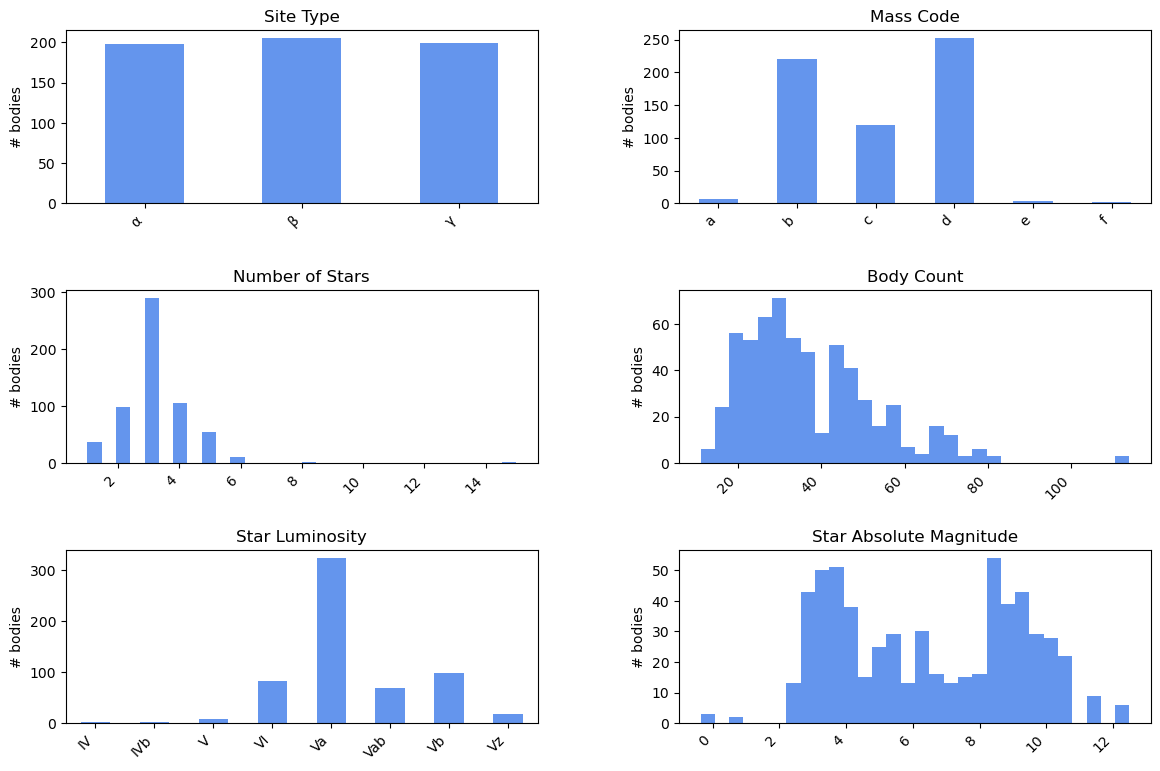

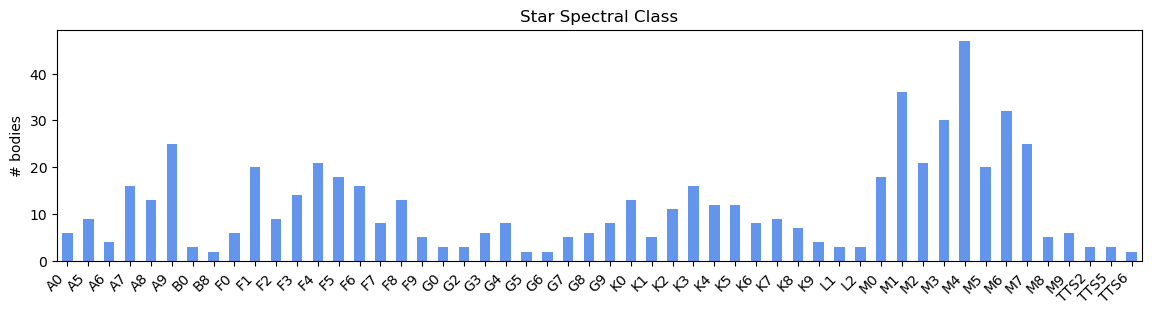

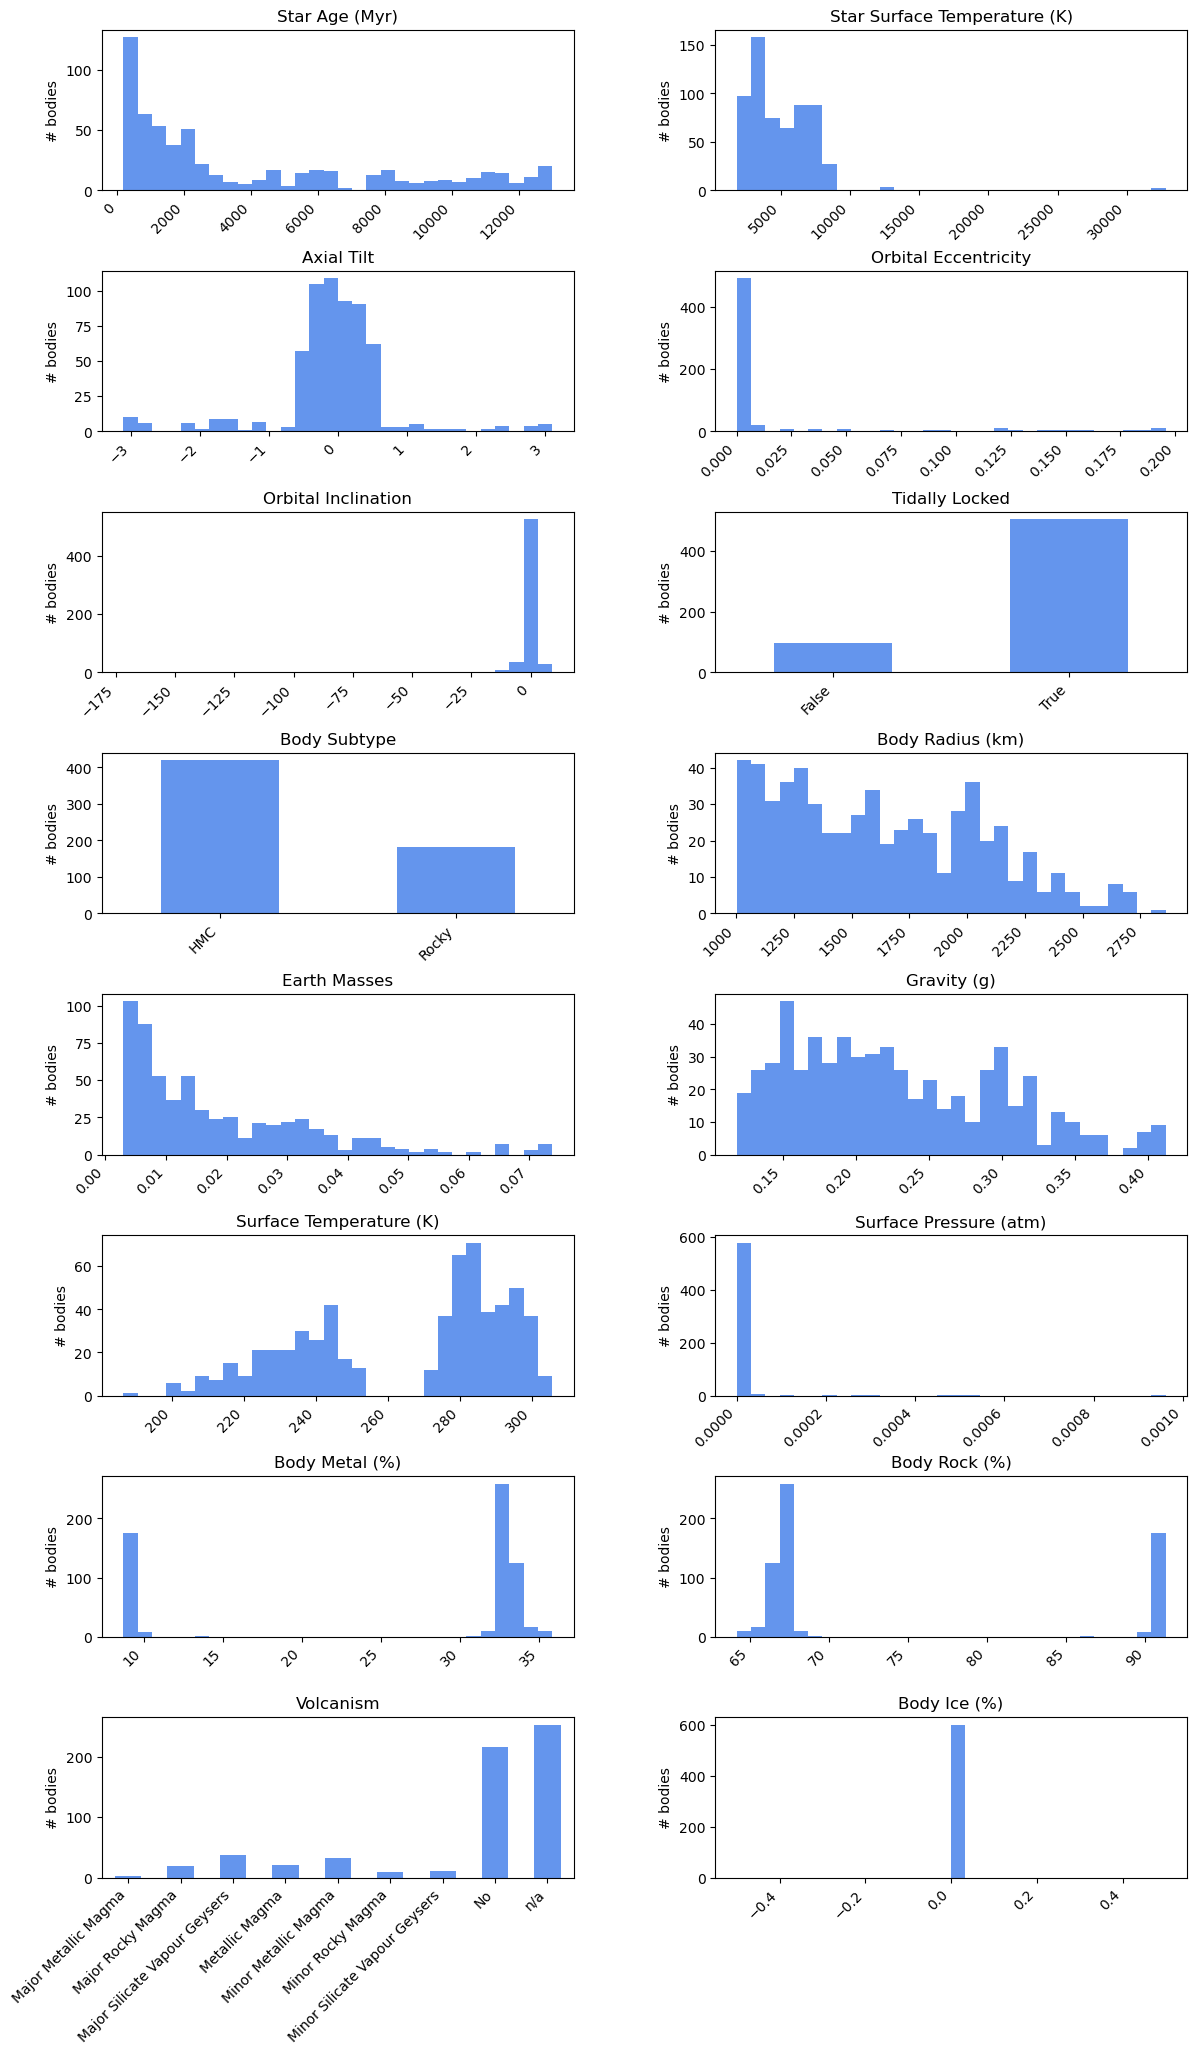

In [4]:
groups = [
    (["Site Type", "Mass Code", "Number of Stars", "Body Count", "Star Luminosity", "Star Absolute Magnitude"], 2),
    (["Star Spectral Class"], 1),
    (["Star Age (Myr)", "Star Surface Temperature (K)", "Axial Tilt", "Orbital Eccentricity", "Orbital Inclination", "Tidally Locked",
      "Body Subtype", "Body Radius (km)", "Earth Masses", "Gravity (g)", "Surface Temperature (K)", "Surface Pressure (atm)",
      "Body Metal (%)", "Body Rock (%)", "Volcanism", "Body Ice (%)"], 2)
]

for columns, ncols in groups:
    nrows = (len(columns) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows), squeeze=False, gridspec_kw={"hspace": 0.5, "wspace": 0.3})
    for ax, column in zip(axes.ravel(), columns):
        data = processed_data[column]
        if pd.api.types.is_numeric_dtype(data):
            data.plot.hist(ax=ax, bins=30, color="cornflowerblue")
        else:
            data.value_counts().sort_index().plot.bar(ax=ax, color="cornflowerblue")
        ax.set(title=column, xlabel="", ylabel="# bodies")
        ax.tick_params(axis="x", rotation=45)
        plt.setp(ax.get_xticklabels(), ha="right")
    for ax in axes.ravel()[len(columns):]:
        ax.remove()
    plt.show()

### Body gravity

Min: 0.1186094626
Max: 0.4121033955


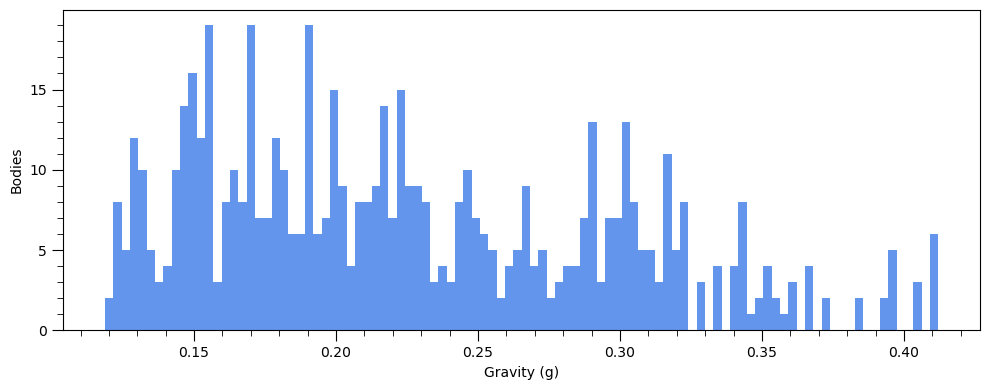

In [5]:
histogram(
    "Gravity (g)",
    colors="cornflowerblue",
    x_major=0.05,
    x_minor=0.01
)

### Axial Tilt

Min: -3.114253
Max: 3.110788


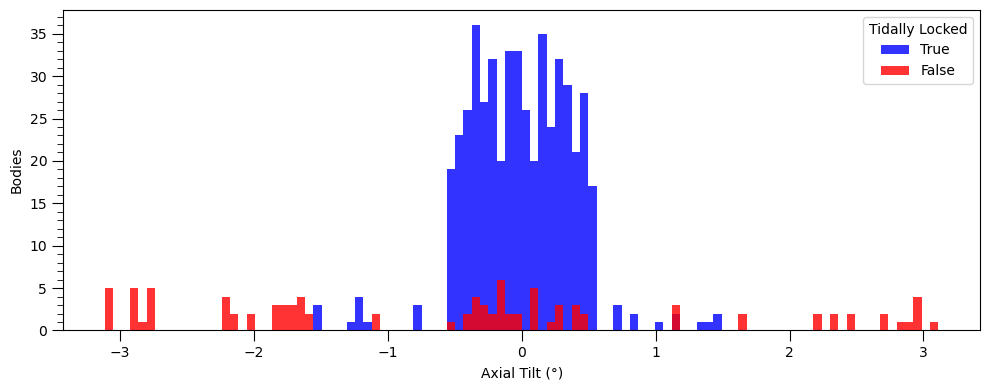

In [6]:
histogram(
    "Axial Tilt",
    xlabel="Axial Tilt (°)",
    legend_title="Tidally Locked",
    groups={"True": "True", "False": "False"},
    colors={"True": "blue", "False": "red"}
)

Min: -3.114253
Max: 3.110788


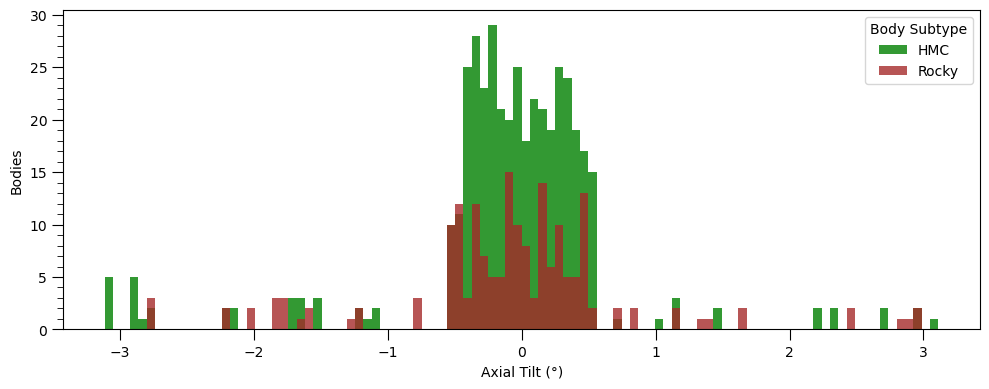

In [7]:
histogram(
    "Axial Tilt",
    xlabel="Axial Tilt (°)",
    legend_title="Body Subtype",
    groups={"HMC": "HMC", "Rocky": "Rocky"},
    colors={"HMC": "green", "Rocky": "brown"}
)

### Tidal lock

Min: 180
Max: 13010


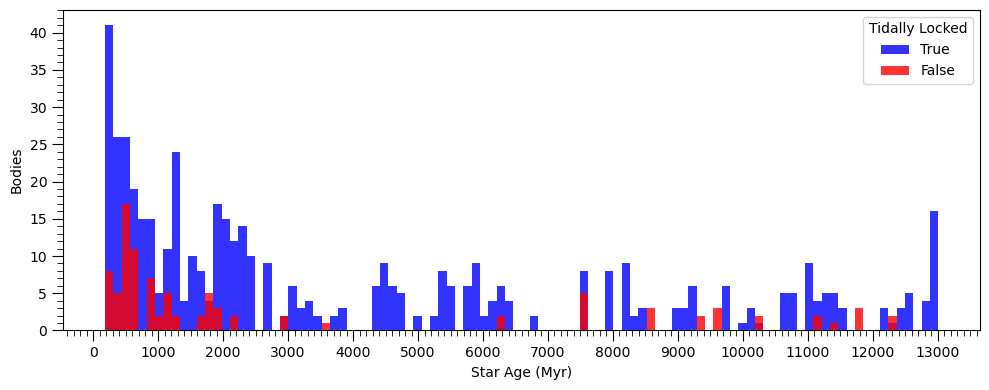

In [8]:
histogram(
    "Star Age (Myr)",
    xlabel="Star Age (Myr)",
    legend_title="Tidally Locked",
    groups={"True": "True", "False": "False"},
    colors={"True": "blue", "False": "red"},
    x_major=1000,
    x_minor=100
)

### Surface Temperature

Min: 186.424805
Max: 305.600372


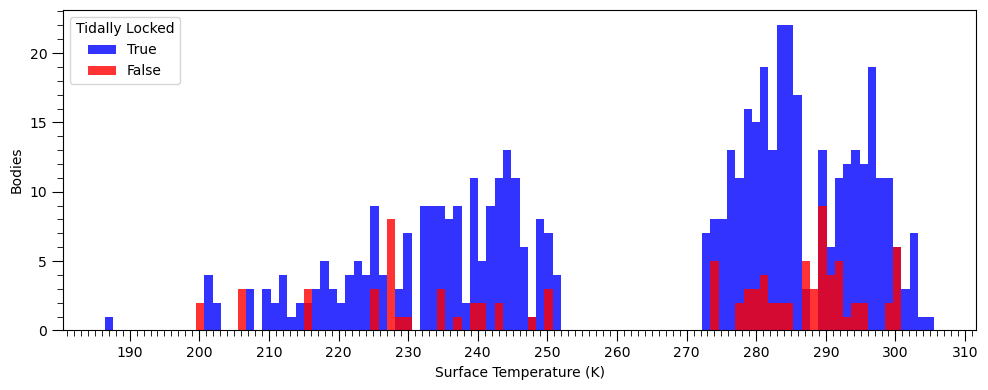

In [9]:
histogram(
    "Surface Temperature (K)",
    legend_title="Tidally Locked",
    groups={"True": "True", "False": "False"},
    colors={"True": "blue", "False": "red"},
    x_major=10,
    x_minor=1
)

Min: 186.424805
Max: 305.600372


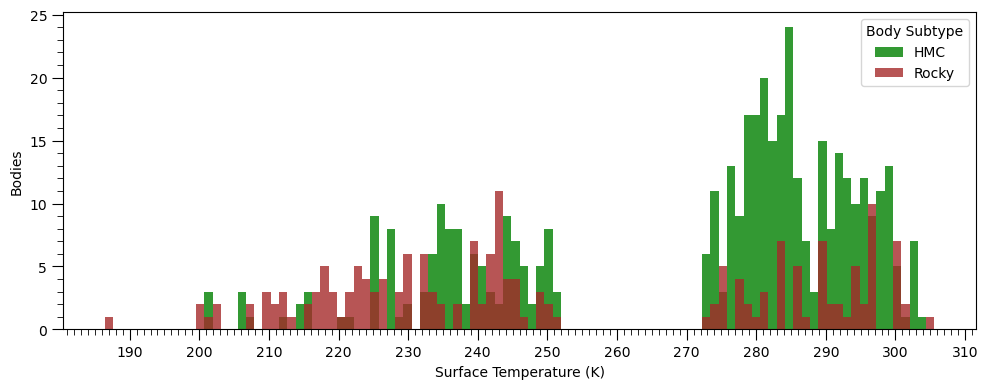

In [10]:
histogram(
    "Surface Temperature (K)",
    legend_title="Body Subtype",
    groups={"HMC": "HMC", "Rocky": "Rocky"},
    colors={"HMC": "green", "Rocky": "brown"},
    x_major=10,
    x_minor=1
)

Min: 186.424805
Max: 305.600372


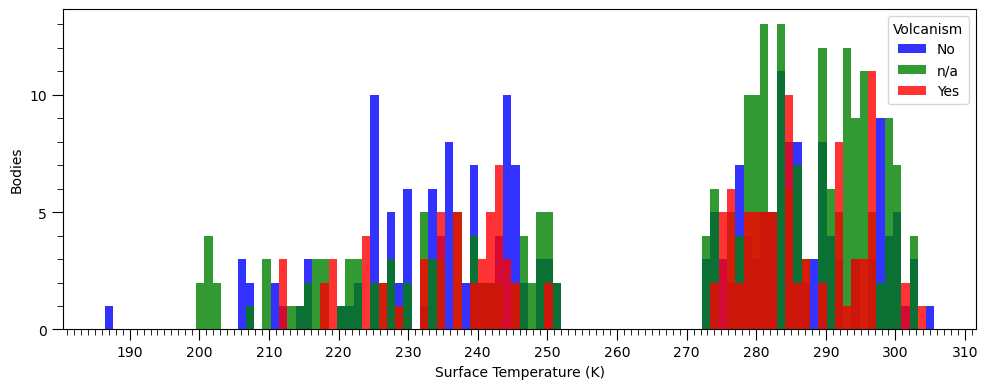

In [11]:
values = processed_data["Volcanism"].dropna().unique()
groups = {"No": "No", "n/a": "n/a", "Yes": [v for v in values if v not in ["No", "n/a"]]}

histogram(
    "Surface Temperature (K)",
    groups=groups,
    colors={"No": "blue", "n/a": "green", "Yes": "red"},
    legend_title="Volcanism",
    x_major=10,
    x_minor=1
)

Min: 186.424805
Max: 305.600372


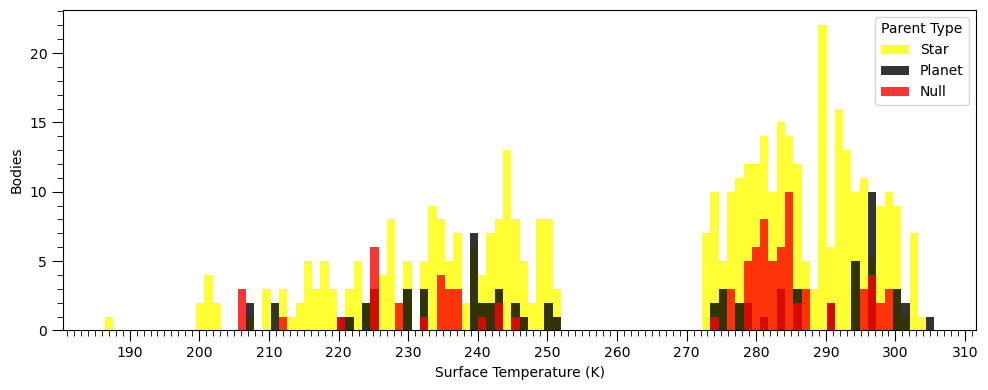

In [12]:
histogram(
    "Surface Temperature (K)",
    legend_title="Parent Type",
    groups={"Star": "Star", "Planet": "Planet", "Null": "Null"},
    colors={"Star": "yellow", "Planet": "black", "Null": "red"},
    x_major=10,
    x_minor=1
)

### Surface Pressure

Min: 0.0
Max: 0.0009608918431


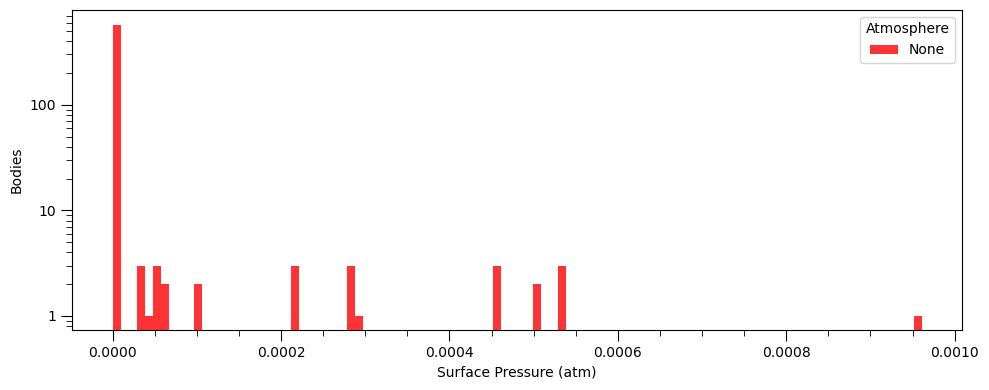

In [13]:
histogram(
    "Surface Pressure (atm)",
    legend_title="Atmosphere",
    groups={"None": "none"},
    colors={"None": "red"},
    x_major=0.0002,
    x_minor=0.00005,
    yscale="log"
)

Min: 0.0
Max: 0.0009608918431


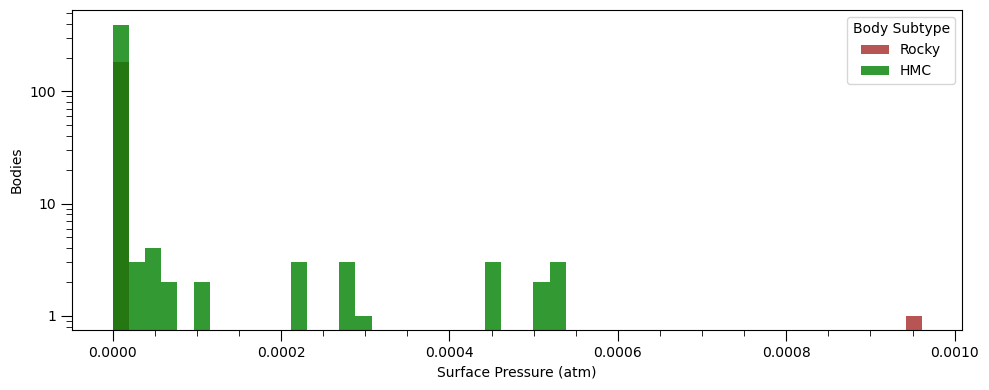

In [14]:
histogram(
    "Surface Pressure (atm)",
    groups={"Rocky": "Rocky", "HMC": "HMC"},
    colors={"Rocky": "brown", "HMC": "green"},
    legend_title="Body Subtype",
    bins=50,
    x_major=0.0002,
    x_minor=0.00005,
    yscale="log"
)

Min: 0.0
Max: 0.0009608918431


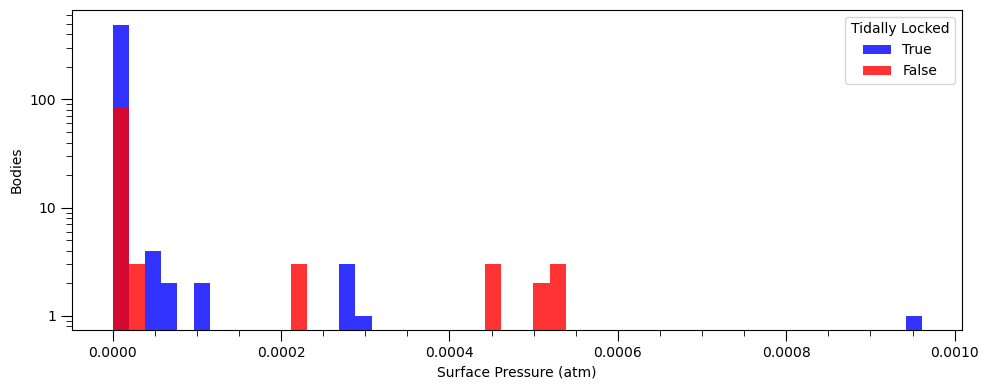

In [24]:
histogram(
    "Surface Pressure (atm)",
    groups={"True": "True", "False": "False"},
    colors={"True": "blue", "False": "red"},
    legend_title="Tidally Locked",
    bins=50,
    x_major=0.0002,
    x_minor=0.00005,
    yscale="log"
)

Min: 0.0
Max: 0.0009608918431


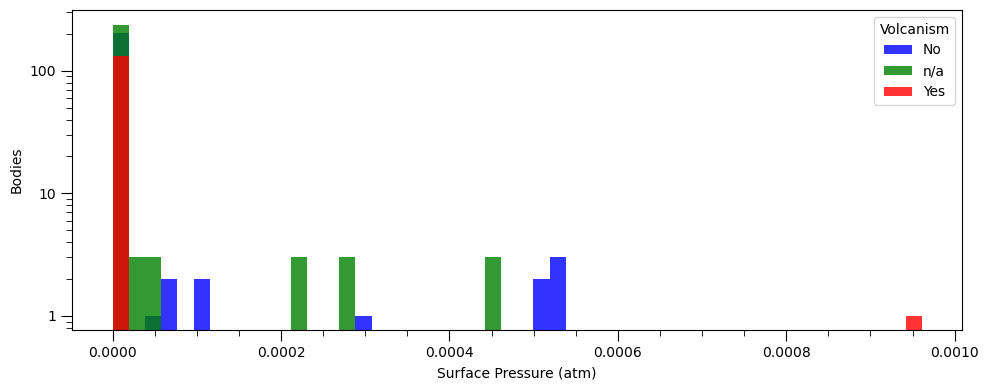

In [16]:
values = processed_data["Volcanism"].dropna().unique()
groups = {"No": "No", "n/a": "n/a", "Yes": [v for v in values if v not in ["No", "n/a"]]}

histogram(
    "Surface Pressure (atm)",
    groups=groups,
    colors={"No": "blue", "n/a": "green", "Yes": "red"},
    legend_title="Volcanism",
    bins=50,
    x_major=0.0002,
    x_minor=0.00005,
    yscale="log"
)

### Body Mass

Min: 0.002968
Max: 0.073801


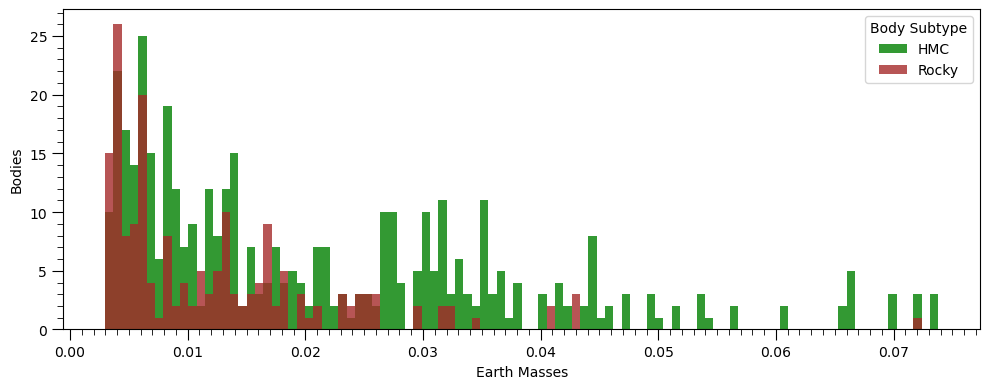

In [17]:
histogram(
    "Earth Masses",
    groups={"HMC": "HMC", "Rocky": "Rocky"},
    colors={"HMC": "green", "Rocky": "brown"},
    legend_title="Body Subtype",
    x_major=0.01,
    x_minor=0.001
)

### Scatter plots

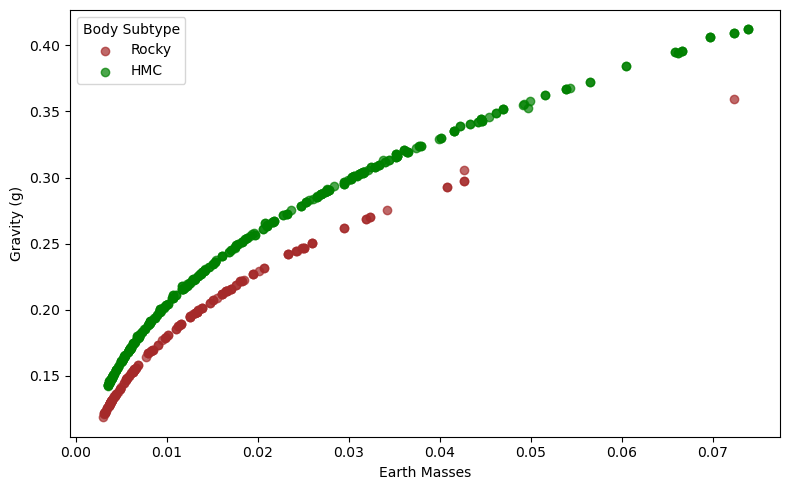

In [18]:
scatter_plot(
    "Earth Masses",
    "Gravity (g)",
    groups={"Rocky": "Rocky", "HMC": "HMC"},
    colors={"Rocky": "brown", "HMC": "green"},
    legend_title="Body Subtype"
)

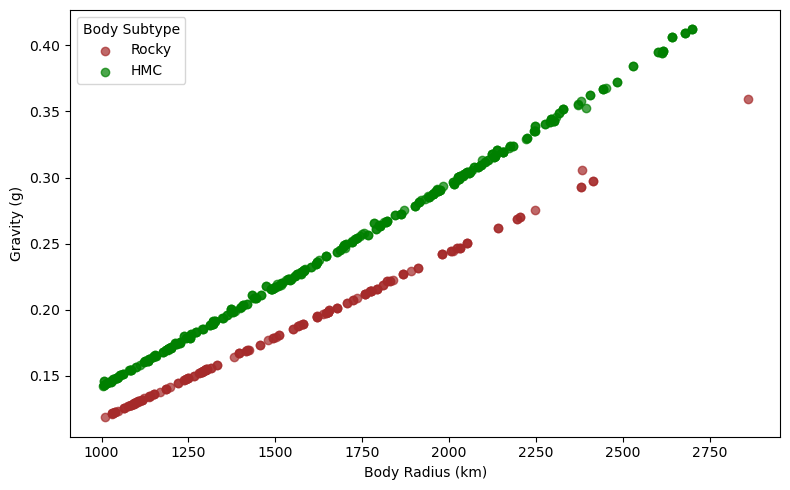

In [19]:
scatter_plot(
    "Body Radius (km)",
    "Gravity (g)",
    groups={"Rocky": "Rocky", "HMC": "HMC"},
    colors={"Rocky": "brown", "HMC": "green"},
    legend_title="Body Subtype"
)

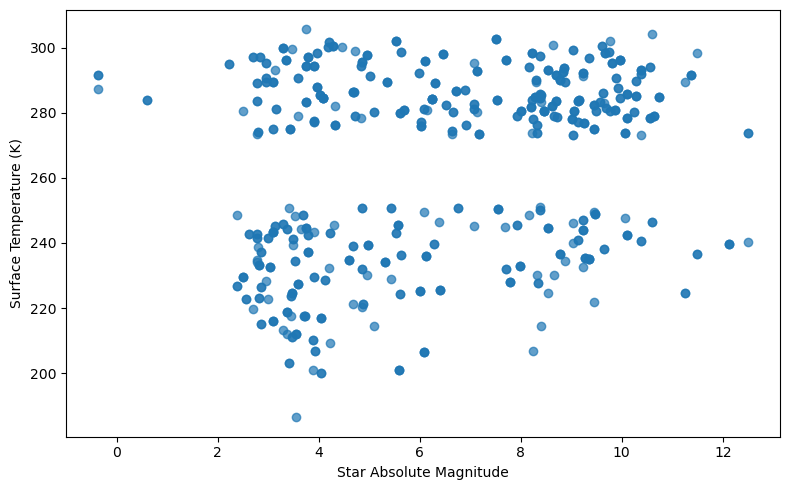

In [20]:
scatter_plot(
    "Star Absolute Magnitude",
    "Surface Temperature (K)"
)

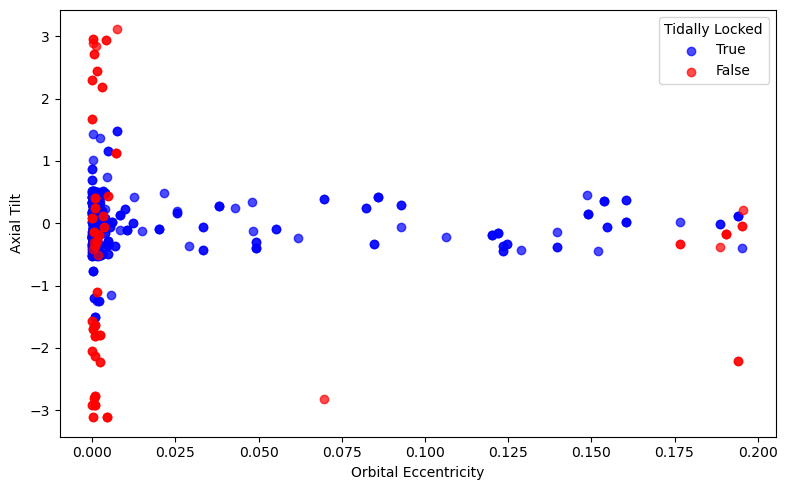

In [21]:
scatter_plot(
    "Orbital Eccentricity",
    "Axial Tilt",
    groups={"True": "True", "False": "False"},
    colors={"True": "blue", "False": "red"},
    legend_title="Tidally Locked"
)

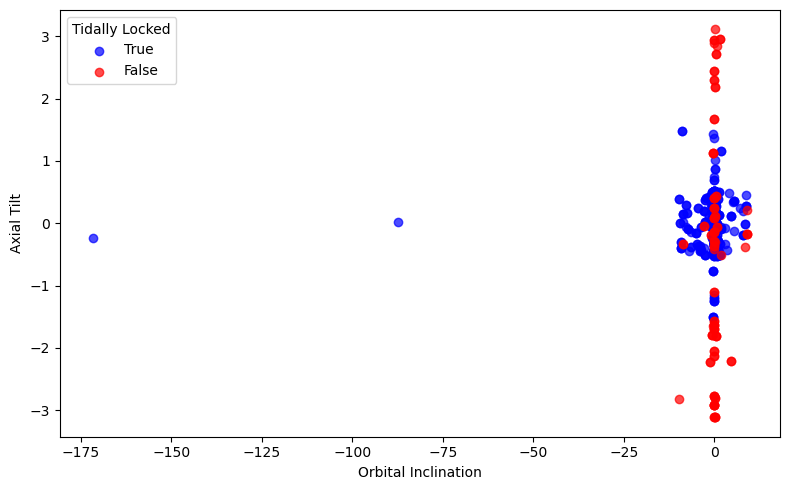

In [22]:
scatter_plot(
    "Orbital Inclination",
    "Axial Tilt",
    groups={"True": "True", "False": "False"},
    colors={"True": "blue", "False": "red"},
    legend_title="Tidally Locked"
)

### Materials

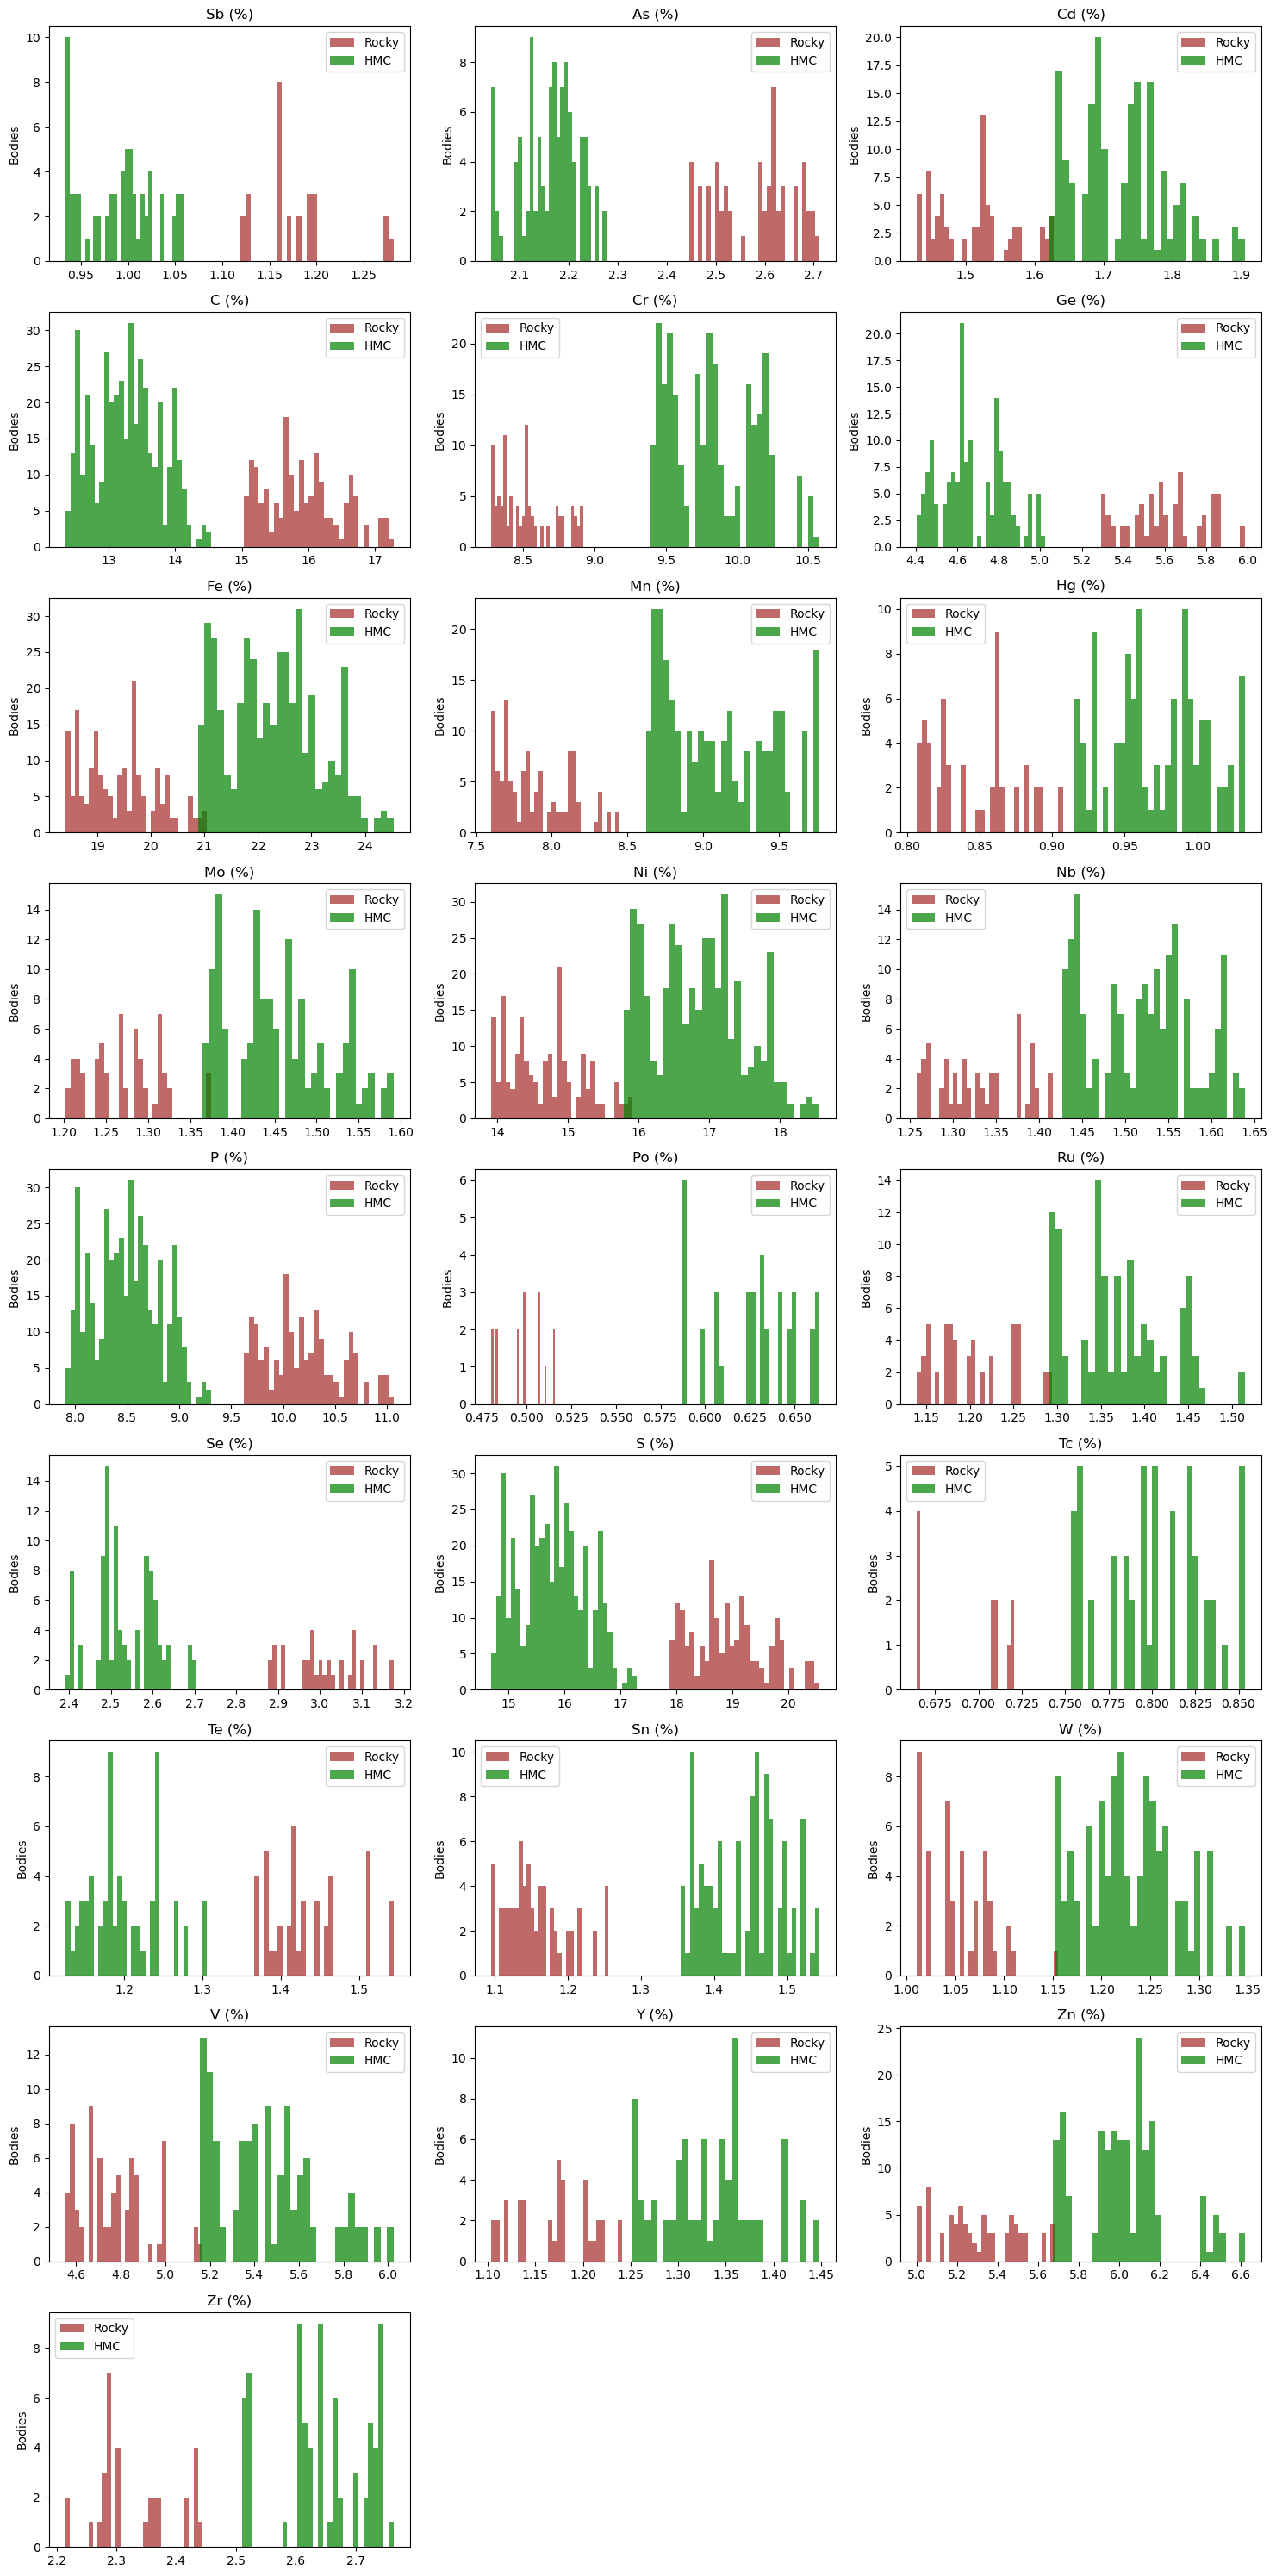

In [23]:
elements = processed_data.filter(regex=r"^[A-Z][a-z]? \(%\)$").columns

fig, axes = plt.subplots((len(elements) + 2) // 3, 3, figsize=(15, 30))
axes = axes.ravel()

for ax, element in zip(axes, elements):
    values = pd.to_numeric(processed_data[element], errors="coerce")

    for subtype, color in {"Rocky": "brown", "HMC": "green"}.items():
        mask = processed_data["Body Subtype"].eq(subtype) & values.gt(0)
        ax.hist(values[mask], bins=30, color=color, alpha=0.7, label=subtype)

    ax.set(title=element, ylabel="Bodies")
    ax.legend()

for ax in axes[len(elements):]:
    ax.remove()

plt.tight_layout()
plt.show()